# Домашнее задание 0
В этом домашнем задании мы рассмотрим основы линейной алгебры, NumPy и обработку изображений с использованием Python.

Одна из целей этого домашнего задания — научиться уверенно находить и использовать полезные библиотечные функции. 
Если не указано специально, то в коде в ответах на вопросы можно эффективные известные методы, а не писать их реализацию самостоятельно. 

# Введение

In [1]:
# Imports the print function from newer versions of python
from __future__ import print_function

import math
import random
import numpy as np
import time
from PIL import Image

from skimage import color, io

import matplotlib.pyplot as plt
# This code is to make matplotlib figures appear inline in the
# notebook rather than in a new window.
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# Вопрос 1: Линейная алгебра и NumPy

## Вопрос 1.1
Задайте указанные массивы, используя numpy. Массив $M$ как $(4, 3)$, $a$ как $(1, 3)$ вектор строку и $b$ как $(3, 1)$ вектор-столбец:

$$M = \begin{bmatrix}
1 & 2 & 3 \\
4 & 5 & 6 \\
7 & 8 & 9 \\
10 & 11 & 12 \end{bmatrix}
$$

$$a = \begin{bmatrix}
1 & 1 & 0
\end{bmatrix}
$$

$$b = \begin{bmatrix}
-1 \\ 2 \\ 5
\end{bmatrix}  
$$

In [2]:
### YOUR CODE HERE
M = np.arange(1,13).reshape(4,3)
a = np.array([1, 1, 0])[np.newaxis, :]
b = np.array([-1, 2, 5])[:, np.newaxis]
### END CODE HERE
print("M = \n", M)
print("The size of M is: ", M.shape)
print()
print("a = ", a)
print("The size of a is: ", a.shape)
print()
print("b = ", b)
print("The size of b is: ", b.shape)

M = 
 [[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]]
The size of M is:  (4, 3)

a =  [[1 1 0]]
The size of a is:  (1, 3)

b =  [[-1]
 [ 2]
 [ 5]]
The size of b is:  (3, 1)


## Вопрос 1.2
Реализуйте `dot_product()` метод для вычисления $a^Tb$. Можно обратиться к `np.dot()`

In [3]:
def dot_product(a, b):
    """Implement dot product between the two vectors: a and b.

    Args:
        a: numpy array of shape (x, n)
        b: numpy array of shape (n, x)

    Returns:
        out: numpy array of shape (x, x) (scalar if x = 1)
    """
    out = None
    ### YOUR CODE HERE
    out = np.dot(a, b)
    ### END YOUR CODE
    return out

In [4]:
# Ответ должен быть [[1]].
aDotB = dot_product(a, b)
print(aDotB)
print("The size is: ", aDotB.shape)

[[1]]
The size is:  (1, 1)


## Вопрос 1.3
Реализуйте метод `complicated_matrix_function()` и используйте его для вычисления $(ab)Ma^T$

ВАЖНО: Метод `complicated_matrix_function()` ожидает, что все входные данные будут двумерными массивами numpy, а не одномерными массивами. Это важное различие, поскольку двумерные массивы можно транспонировать, а одномерные — нет.

Для транспонирования двумерного массива можно использовать синтаксис `array.T`

In [5]:
def complicated_matrix_function(M, a, b):
    """Implement (a * b) * (M * a.T).

    (optional): Use the `dot_product(a, b)` function you wrote above
    as a helper function.

    Args:
        M: numpy matrix of shape (x, n).
        a: numpy array of shape (1, n).
        b: numpy array of shape (n, 1).

    Returns:
        out: numpy matrix of shape (x, 1).
    """
    out = None
    ### YOUR CODE HERE
    out = (dot_product(a, b))*(M@a.T)
    ### END YOUR CODE

    return out

In [6]:
# Ожидаемый ответ $[[3], [9], [15], [21]]$,  shape(4, 1).
ans = complicated_matrix_function(M, a, b)
print(ans)
print()
print("The size is: ", ans.shape)

[[ 3]
 [ 9]
 [15]
 [21]]

The size is:  (4, 1)


In [7]:
M_2 = np.array(range(4)).reshape((2,2))
a_2 = np.array([[1,1]])
b_2 = np.array([[10, 10]]).T
print(M_2.shape)
print(a_2.shape)
print(b_2.shape)
print()

# Ожидаемый ответ $[[20], [100]]$, shape(2, 1).
ans = complicated_matrix_function(M_2, a_2, b_2)
print(ans)
print()
print("The size is: ", ans.shape)

(2, 2)
(1, 2)
(2, 1)

[[ 20]
 [100]]

The size is:  (2, 1)


## Вопрос 1.4

Реализуйте методы `eigen_decomp()` и `get_eigen_values_and_vectors()`. В этом методе выполните разложение на собственные значения следующей матрицы и верните k наибольших собственных значений и соответствующие собственные векторы (k указывается в вызовах методов ниже).

$$M = \begin{bmatrix}
1 & 2 & 3 \\
4 & 5 & 6 \\
7 & 8 & 9 \end{bmatrix}
$$

### Для информации
Разложение на собственные значения имеет конкретное практическое применение. Например, в машинном обучении для уменьшения размерности датасетов, анализа признаков и корреляций. Подробнее можно посмотреть метод PCA, SVD, и другие

In [8]:
def eigen_decomp(M):
    """Implement eigenvalue decomposition.

    (optional): You might find the `np.linalg.eig` function useful.

    Args:
        matrix: numpy matrix of shape (m, m)

    Returns:
        w: numpy array of shape (m,) such that the column v[:,i] is the eigenvector corresponding to the eigenvalue w[i].
        v: Matrix where every column is an eigenvector.
    """
    w = None
    v = None
    ### YOUR CODE HERE
    w, v = np.linalg.eig(M)
    ### END YOUR CODE
    return w, v

In [9]:
def get_eigen_values_and_vectors(M, k):
    """Return top k eigenvalues and eigenvectors of matrix M. By top k
    here we mean the eigenvalues with the top ABSOLUTE values (lookup
    np.argsort for a hint on how to do so.)

    (optional): Use the `eigen_decomp(M)` function you wrote above
    as a helper function

    Args:
        M: numpy matrix of shape (m, m).
        k: number of eigen values and respective vectors to return.

    Returns:
        eigenvalues: list of length k containing the top k eigenvalues
        eigenvectors: list of length k containing the top k eigenvectors
            of shape (m,)
    """
    eigenvalues = []
    eigenvectors = []
    ### YOUR CODE HERE
    w, v = eigen_decomp(M)
    
    sorted_indices = np.argsort(np.abs(w))[::-1]
    top_k_indices = sorted_indices[:k]
    
    eigenvalues = w[top_k_indices]
    eigenvectors = v[:, top_k_indices].T 
    
    eigenvalues = list(eigenvalues)
    eigenvectors = list(eigenvectors)
    ### END YOUR CODE
    return eigenvalues, eigenvectors

In [10]:
# Let's define M.
M = np.array([[1,2,3],[4,5,6],[7,8,9]])

# Now let's grab the first eigenvalue and first eigenvector.
# You should get back a single eigenvalue and a single eigenvector.
val, vec = get_eigen_values_and_vectors(M[:,:3], 1)
print("First eigenvalue =", val[0])
print()
print("First eigenvector =", vec[0])
print()
assert len(vec) == 1

# Now, let's get the first two eigenvalues and eigenvectors.
# You should get back a list of two eigenvalues and a list of two eigenvector arrays.
val, vec = get_eigen_values_and_vectors(M[:,:3], 2)
print("Eigenvalues =", val)
print()
print("Eigenvectors =", vec)
assert len(vec) == 2

First eigenvalue = 16.116843969807043

First eigenvector = [-0.23197069 -0.52532209 -0.8186735 ]

Eigenvalues = [np.float64(16.116843969807043), np.float64(-1.1168439698070416)]

Eigenvectors = [array([-0.23197069, -0.52532209, -0.8186735 ]), array([-0.78583024, -0.08675134,  0.61232756])]


## Вопрос 1.5

В завершение данного раздела давайте реализуем вспомогательную функцию для вычисления евклидова расстояния между двумя n-мерными точками.

В двумерном случае вычисление евклидова расстояния сводится к решению теоремы Пифагора $c = \sqrt{a^2 + b^2}$:

![pythagorean.png](pythagorean.png)

...где, если даны две точки $(x_1, y_1)$ и $(x_2, y_2)$, $a = x_1 - x_2$ и $b = y_1 - y_2$.

В более общем случае, если даны два n-мерных вектора, евклидово расстояние можно вычислить следующим образом:

1. Выполнив поэлементное вычитание между двумя векторами, чтобы получить $n$ разностей.

2. Возведение каждого из $n$ значений разности в квадрат и суммирование квадратов.

4. Извлечение квадратного корня из суммы.

В качестве альтернативы, евклидово расстояние между $n$ векторами $u$ и $v$ можно записать как:

$
\quad\textbf{distance}(u, v) = \sqrt{\sum_{i=1}^n (u_i - v_i)^2}
$

Попробуйте реализовать эту функцию: сначала используя нативный Python с циклом `for` в функции `euclidean_distance_native()`, затем в NumPy **без каких-либо циклов** в функции `euclidean_distance_numpy()`.

In [11]:
def euclidean_distance_native(u, v):
    """Computes the Euclidean distance between two vectors, represented as Python
    lists.

    Args:
        u (List[float]): A vector, represented as a list of floats.
        v (List[float]): A vector, represented as a list of floats.

    Returns:
        float: Euclidean distance between `u` and `v`.
    """
    # First, run some checks:
    assert isinstance(u, list)
    assert isinstance(v, list)
    assert len(u) == len(v)
    result = 0
    # Compute the distance!
    # Notes:
    #  1) Try breaking this problem down: first, we want to get
    #     the difference between corresponding elements in our
    #     input arrays. Then, we want to square these differences.
    #     Finally, we want to sum the squares and square root the
    #     sum.

    ### YOUR CODE HERE
    for i in range(len(u)):
        result += (u[i] - v[i])**2
    return math.sqrt(result)
    ### END YOUR CODE

In [12]:
## Testing native Python function
assert euclidean_distance_native([7.0], [6.0]) == 1.0
assert euclidean_distance_native([7.0, 0.0], [3.0, 3.0]) == 5.0
assert euclidean_distance_native([7.0, 0.0, 0.0], [3.0, 0.0, 3.0]) == 5.0

In [13]:
def euclidean_distance_numpy(u, v):
    """Computes the Euclidean distance between two vectors, represented as NumPy
    arrays.

    Args:
        u (np.ndarray): A vector, represented as a NumPy array.
        v (np.ndarray): A vector, represented as a NumPy array.

    Returns:
        float: Euclidean distance between `u` and `v`.
    """
    # First, run some checks:
    assert isinstance(u, np.ndarray)
    assert isinstance(v, np.ndarray)
    assert u.shape == v.shape

    # Compute the distance!
    # Note:
    #  1) You shouldn't need any loops
    #  2) Some functions you can Google that might be useful:
    #         np.sqrt(), np.sum()
    #  3) Try breaking this problem down: first, we want to get
    #     the difference between corresponding elements in our
    #     input arrays. Then, we want to square these differences.
    #     Finally, we want to sum the squares and square root the
    #     sum.

    ### YOUR CODE HERE
    return np.sqrt(np.sum((u - v)**2))
    ### END YOUR CODE

In [14]:
## Testing NumPy function
assert euclidean_distance_numpy(
    np.array([7.0]),
    np.array([6.0])
) == 1.0
assert euclidean_distance_numpy(
    np.array([7.0, 0.0]),
    np.array([3.0, 3.0])
) == 5.0
assert euclidean_distance_numpy(
    np.array([7.0, 0.0, 0.0]),
    np.array([3.0, 0.0, 3.0])
) == 5.0

Сравним две реализации:

In [15]:
n = 1000

a = [0.0] * n
b = [10.0] * n
a_array = np.array(a)
b_array = np.array(b)

start_time = time.time()
for i in range(10000):
    euclidean_distance_native(a, b)
print("Native:", (time.time() - start_time), "seconds")

start_time = time.time()
for i in range(10000):
    euclidean_distance_numpy(a_array, b_array)
print("NumPy:", (time.time() - start_time), "seconds")

Native: 0.6093459129333496 seconds
NumPy: 0.029242753982543945 seconds


# Часть 2: Обработка изображения

In [16]:

image1_path = 'image1.jpg'
image2_path = 'image2.jpg'

def display(img):
    # Show image
    plt.figure(figsize = (5,5))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

## Вопрос 2.1

Реализуйте метод `load()` ниже. `load()` и `display()` будут использоваться на протяжении всего остального ноутбука.

In [17]:
def load(image_path):
    """Loads an image from a file path.

    HINT: Look up `skimage.io.imread()` function.

    Args:
        image_path: file path to the image.

    Returns:
        out: numpy array of shape(image_height, image_width, 3).
    """
    out = None
    ### YOUR CODE HERE
    out = io.imread(image_path)
    ### END YOUR CODE

    out = out.astype(np.float64) / 255
    return out

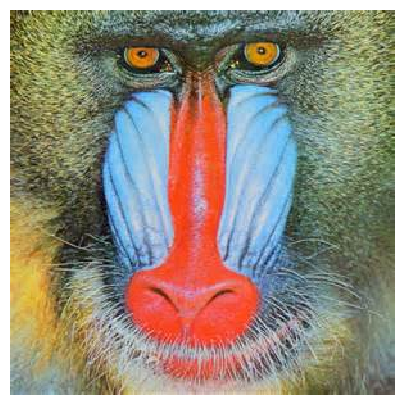

In [18]:
image1 = load(image1_path)

display(image1)

## Вопрос 2.2

Одна из наиболее распространенных операций, которые выполняются при работе с изображениями, — это **кадрирование**, или удаление ненужных внешних областей изображения.

Взгляните на этот код, который мы написали, чтобы обрезать все, кроме глаз нашего бабуина, сверху:

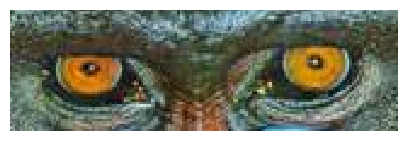

In [19]:
display(image1[10:60, 70:230, :])

Реализуйте метод `crop_image()`, принимая на вход индекс начальной строки, начального столбца, количество строк и столбцов, и выводя обрезанное изображение.

Затем в ячейке ниже попробуйте извлечь квадрат 100x100 из каждого угла исходного изображения `image1`: верхнего левого, верхнего правого, нижнего левого и нижнего правого углов.

In [20]:
def crop_image(image, start_row, start_col, num_rows, num_cols):
    """Crop an image based on the specified bounds.

    Args:
        image: numpy array of shape(image_height, image_width, 3).
        start_row (int): The starting row index we want to include in our cropped image.
        start_col (int): The starting column index we want to include in our cropped image.
        num_rows (int): Number of rows in our desired cropped image.
        num_cols (int): Number of columns in our desired cropped image.

    Returns:
        out: numpy array of shape(num_rows, num_cols, 3).
    """

    out = None

    ### YOUR CODE HERE
    out = image[start_row:start_row + num_rows, start_col:start_col + num_cols, :]
    ### END YOUR CODE

    return out

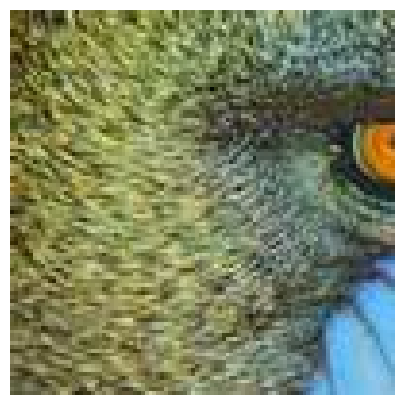

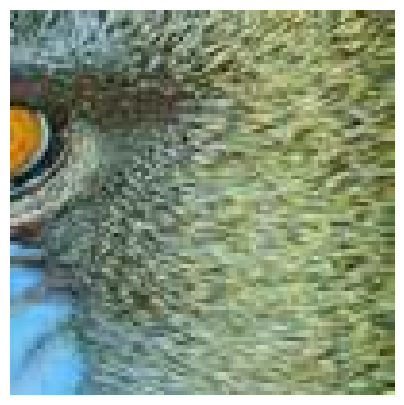

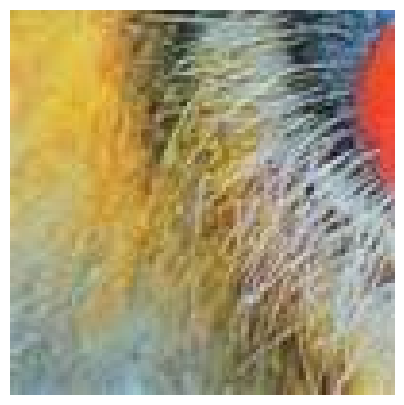

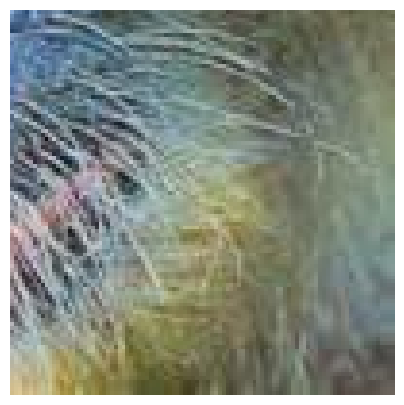

In [21]:
r, c = image1.shape[0], image1.shape[1]

top_left_corner = crop_image(image1, 0, 0, 100, 100)
top_right_corner = crop_image(image1, 0, c-100, 100, 100)
bottom_left_corner = crop_image(image1, r-100, 0, 100, 100)
bottom_right_corner = crop_image(image1, r-100, c-100, 100, 100)

display(top_left_corner)
display(top_right_corner)
display(bottom_left_corner)
display(bottom_right_corner)

## Вопрос 2.3

Реализуйте метод `dim_image()`, преобразуя изображения в соответствии с формулой $x_n = 0.5*x_p^2$ для каждого пикселя, где $x_n$ — новое значение, а $x_p$ — исходное значение.

Примечание: Поскольку все значения пикселей изображения находятся в диапазоне $[0, 1]$, приведенная выше формула приведет к уменьшению значений этих пикселей и, следовательно, к затемнению изображения.

In [22]:
def dim_image(image):
    """Change the value of every pixel by following

                        x_n = 0.5*x_p^2

    where x_n is the new value and x_p is the original value.

    Args:
        image: numpy array of shape(image_height, image_width, 3).

    Returns:
        out: numpy array of shape(image_height, image_width, 3).
    """

    out = None

    ### YOUR CODE HERE
    out = 0.5 * (image ** 2)
    ### END YOUR CODE

    return out

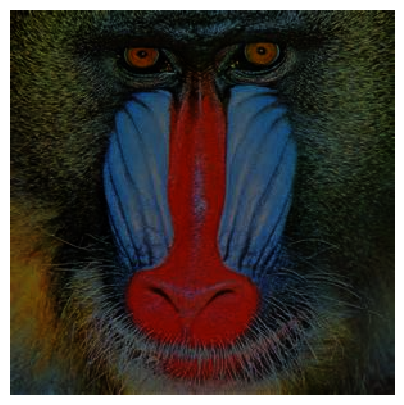

In [23]:
new_image = dim_image(image1)
display(new_image)

## Вопрос 2.4

Давайте попробуем ещё одну часто используемую операцию: изменение размера изображения. Реализация метода ниже - это nearest neighbor interpolation (масштабирование изображения по ближайшему соседу)

В общих чертах, изменение размера изображения должно выглядеть примерно так:

1. Мы создаём (изначально пустой) выходной массив желаемого размера, `output_image`.
2. Мы перебираем каждую позицию пикселя `(i,j)` в выходном изображении.

— Для каждого выходного пикселя мы вычисляем соответствующий входной пиксель `(input_i, input_j)`.

— копируем вычисленный пиксель в нужное положение выходного изображения.
3. Мы возвращаем изменённое выходное изображение.

Мы хотим, чтобы `input_i` и `input_j` увеличивались пропорционально `i` и `j` соответственно:

— `input_i` можно вычислить как `int(i * row_scale_factor)`.

— `input_j` можно вычислить как `int(j * col_scale_factor)`.

...где `int()` — это операция Python, принимающая число с плавающей запятой и округляющая значения. округлите изображение до ближайшего целого числа, а `row_scale_factor` и `col_scale_factor` — это константы, вычисленные на основе размеров входного/выходного изображения.

Попробуйте определить, какими должны быть значения `row_scale_factor` и `col_scale_factor`, а затем реализуйте этот алгоритм в методе `resize_image()`! Затем запустите ячейки ниже, чтобы протестировать свой алгоритм изменения размера изображения!

Когда вы уменьшите размер изображения бабуина до 16x16, вы должны получить результат, который будет выглядеть примерно так:

![16_16_baboon.png](16_16_baboon.png)

Когда вы растянете его по горизонтали до 50x400, вы должны получить:

![50_400_baboon.png](50_400_baboon.png)

In [24]:
def resize_image(input_image, output_rows, output_cols):
    """Resize an image using the nearest neighbor method.

    Args:
        input_image (np.ndarray): RGB image stored as an array, with shape
            `(input_rows, input_cols, 3)`.
        output_rows (int): Number of rows in our desired output image.
        output_cols (int): Number of columns in our desired output image.

    Returns:
        np.ndarray: Resized image, with shape `(output_rows, output_cols, 3)`.
    """
    input_rows, input_cols, channels = input_image.shape
    assert channels == 3

    # 1. Create the resized output image
    output_image = np.zeros(shape=(output_rows, output_cols, 3))

    # 2. Populate the `output_image` array using values from `input_image`
    #    > This should require two nested for loops!

    ### YOUR CODE HERE
    row_scale = input_rows / output_rows
    col_scale = input_cols / output_cols
    
    indices = np.indices((output_rows, output_cols))
    
    in_rows = (indices[0] * row_scale).astype(int)
    in_cols = (indices[1] * col_scale).astype(int)
    
    output_image = input_image[in_rows, in_cols]
    ### END YOUR CODE

    # 3. Return the output image
    return output_image

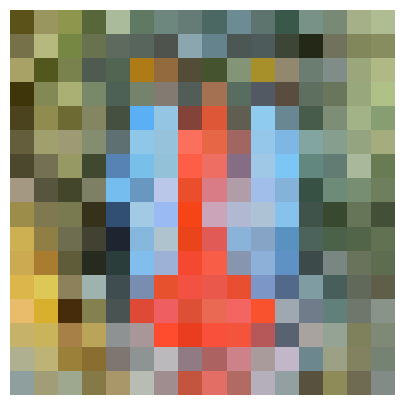

In [25]:
display(resize_image(image1, 16, 16))

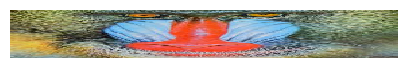

In [26]:
display(resize_image(image1, 50, 400))

**Вопрос:** В описанном выше алгоритме изменения размера выходное изображение заполняется путем перебора индексов выходного изображения. Можно ли реализовать изменение размера изображения путем перебора индексов входного изображения? Чем отличаются эти два подхода?

> 1 входной пиксель → несколько выходных пикселей, следовательно будет работать дольше, сам алгоритм будет сложнее, так как придется вычислять отдеьно случаи перекрытия индексов, 

## Вопрос 2.5

Ещё одна операция, которую вы можете попробовать реализовать, — это **поворот изображения**. 

#### а) Поворот 2D-координат (5 баллов)

Прежде чем мы начнем думать о вращении изображений, давайте рассмотрим вращение координат `(x, y)`:

![coordinate_rotation.png](coordinate_rotation.png)

Используя `np.cos()` и `np.sin()`, реализуйте метод `rotate2d()` для вычисления координат $(x', y')$, повернутых на угол тета (радиан) от $(x, y)$.

После реализации функции протестируйте свою реализацию ниже, используя операторы assert. 

In [29]:
def rotate2d(point, theta):
    """Rotate a 2D coordinate by some angle theta.

    Args:
        point (np.ndarray): A 1D NumPy array containing two values: an x and y coordinate.
        theta (float): An theta to rotate by, in radians.

    Returns:
        np.ndarray: A 1D NumPy array containing your rotated x and y values.
    """
    assert point.shape == (2,)
    assert isinstance(theta, float)

    # Reminder: np.cos() and np.sin() will be useful here!

    ### YOUR CODE HERE
    x, y = point
    
    x_rotated = x * np.cos(theta) - y * np.sin(theta)
    y_rotated = x * np.sin(theta) + y * np.cos(theta)
    
    return np.array([x_rotated, y_rotated])
    ### END YOUR CODE

In [30]:
assert rotate2d(np.array([1.0, 0.0]), 0.0).shape == (
    2,
), "Output shape incorrect!"
assert np.allclose(
    rotate2d(np.array([1.0, 0.0]), 0.0), np.array([1.0, 0.0])
), ""
assert np.allclose(
    rotate2d(np.array([1.0, 0.0]), np.pi / 2.0), np.array([0.0, 1.0])
), ""

Запустите ячейку ниже, чтобы визуализировать точку, вращающуюся вокруг начала координат на ряд равномерно расположенных углов! Вы должны увидеть 30 точек. 

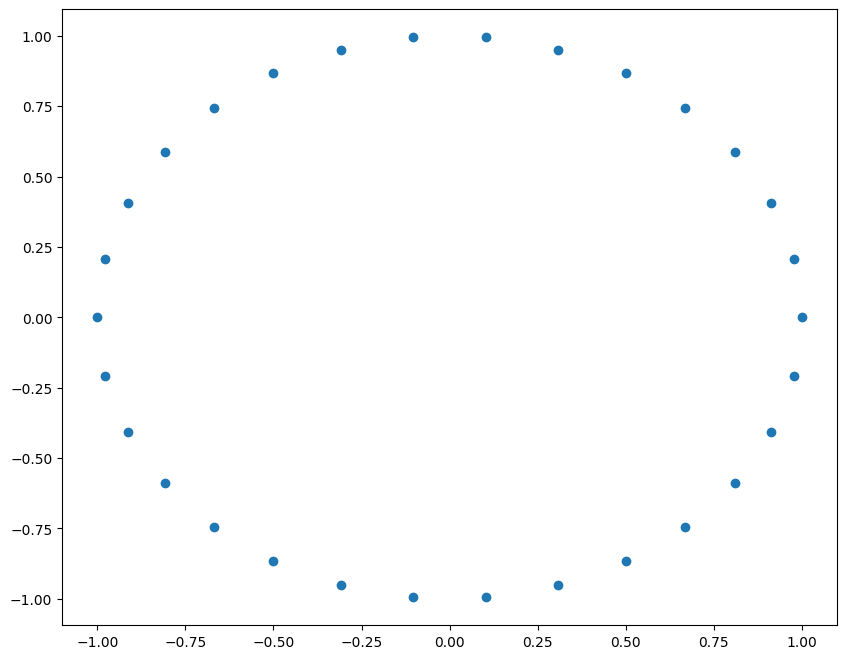

In [31]:
# Visualize a point being rotated around the origin
# We'll use the matplotlib library for this!
import matplotlib.pyplot as plt

points = np.zeros((30, 2))
for i in range(30):
    points[i, :] = rotate2d(np.array([1.0, 0.0]), i / 30.0 * (2 * np.pi))

plt.scatter(points[:, 0], points[:, 1])
plt.show()

**Вопрос:** В настоящее время наша функция вращает точки только вокруг начала координат (0,0). Используя ту же функцию `rotate2d`, как можно повернуть точку вокруг центра, который не находится в (0,0)? **Вам это понадобится при реализации вращения изображения ниже!**

> *Ваш ответ здесь!*


#### b) Поворот изображения (10 баллов)

Реализуйте функцию `rotate_image(input_image, theta)` для поворота изображения. 

Для входного угла $\pi/4$ (45 градусов) ожидаемый результат:

![rotated_output.png](rotated_output.png)

**Подсказки:**
- рекомендуется основывать ваш код на реализации функции `resize_image()` и применять тот же общий подход, что и раньше. Пройдитесь по каждому пикселю выходного изображения `(i, j)`, затем заполните его цветом из соответствующего входного пикселя `(input_i, input_j)`. В этом случае обратите внимание, что выходное и входное изображения должны быть одинакового размера.
- Если вы столкнетесь с пикселем на выходе, у которого соответствующие входные координаты `input_i` и `input_j` недействительны, вы можете просто проигнорировать этот пиксель или установить его в черный цвет.
- В приведенном выше ожидаемом результате мы вращаем каждую координату вокруг центра изображения, а не вокруг начала координат. (начало координат находится в верхнем левом углу)


In [32]:
def rotate_image(input_image, theta):
    """Rotate an image by some angle theta.

    Args:
        input_image (np.ndarray): RGB image stored as an array, with shape
            `(input_rows, input_cols, 3)`.
        theta (float): Angle to rotate our image by, in radians.

    Returns:
        (np.ndarray): Rotated image, with the same shape as the input.
    """
    input_rows, input_cols, channels = input_image.shape
    assert channels == 3

    # 1. Create an output image with the same shape as the input
    output_image = np.zeros_like(input_image)

    ### YOUR CODE HERE
    center_row = input_rows / 2
    center_col = input_cols / 2
    
    cos_theta = np.cos(theta)
    sin_theta = np.sin(theta)
    
    for i in range(input_rows):
        for j in range(input_cols):
            shifted_row = i - center_row
            shifted_col = j - center_col
            
            input_row = shifted_row * cos_theta - shifted_col * sin_theta
            input_col = shifted_row * sin_theta + shifted_col * cos_theta
            
            input_row = input_row + center_row
            input_col = input_col + center_col
            
            input_row_round = int(round(input_row))
            input_col_round = int(round(input_col))
            
            if (0 <= input_row_round < input_rows and 
                0 <= input_col_round < input_cols):
                output_image[i, j] = input_image[input_row_round, input_col_round]
    ### END YOUR CODE

    # 3. Return the output image
    return output_image

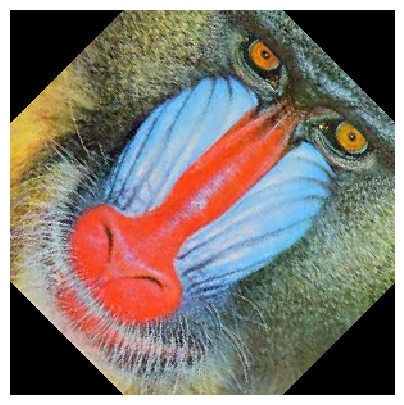

In [33]:
# Test that your output matches the expected output
display(rotate_image(image1, np.pi / 4.0))